In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Our portfolio — 5 Nifty 50 stocks
tickers = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'WIPRO.NS']

# Download 3 years of data
data = yf.download(tickers, start="2021-01-01", end="2024-01-01")['Close']

# Calculate daily returns
returns = data.pct_change().dropna()

print("Data downloaded successfully!")
print(f"Shape: {returns.shape}")
print(f"\nFirst few rows:")
print(returns.head())

[*********************100%***********************]  5 of 5 completed

Data downloaded successfully!
Shape: (740, 5)

First few rows:
Ticker      HDFCBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS  WIPRO.NS
Date                                                              
2021-01-04    -0.006351  0.022056     0.001685  0.037975  0.021386
2021-01-05     0.007556  0.004308    -0.012432  0.017619  0.024975
2021-01-06    -0.004311 -0.009043    -0.026372 -0.013417  0.000246
2021-01-07    -0.003027 -0.015560    -0.001619 -0.006128  0.000861
2021-01-08     0.010874  0.039575     0.011799  0.029049  0.057652


In [3]:
# Key stats for each stock
stats = pd.DataFrame({
    'Annual Return (%)': returns.mean() * 252 * 100,
    'Annual Volatility (%)': returns.std() * np.sqrt(252) * 100,
    'Sharpe Ratio': (returns.mean() * 252) / (returns.std() * np.sqrt(252))
})

print(stats.round(4))

             Annual Return (%)  Annual Volatility (%)  Sharpe Ratio
Ticker                                                             
HDFCBANK.NS             9.6382                22.4883        0.4286
INFY.NS                12.1017                24.1410        0.5013
RELIANCE.NS            14.8273                23.6776        0.6262
TCS.NS                 13.0389                20.9318        0.6229
WIPRO.NS               10.3144                25.3481        0.4069


In [5]:
# Simulate 5000 random portfolios
np.random.seed(42)
num_portfolios = 5000
num_stocks = len(tickers)

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    # Random weights that sum to 1
    weights = np.random.random(num_stocks)
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    # Portfolio return and volatility
    port_return = np.sum(returns.mean() * weights) * 252
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
    sharpe = port_return / port_volatility
    
    results[0, i] = port_return * 100      # Annual return %
    results[1, i] = port_volatility * 100  # Annual volatility %
    results[2, i] = sharpe                  # Sharpe ratio

print("5000 portfolios simulated!")
print(f"Best Sharpe Ratio found: {results[2].max():.4f}")

5000 portfolios simulated!
Best Sharpe Ratio found: 0.7825


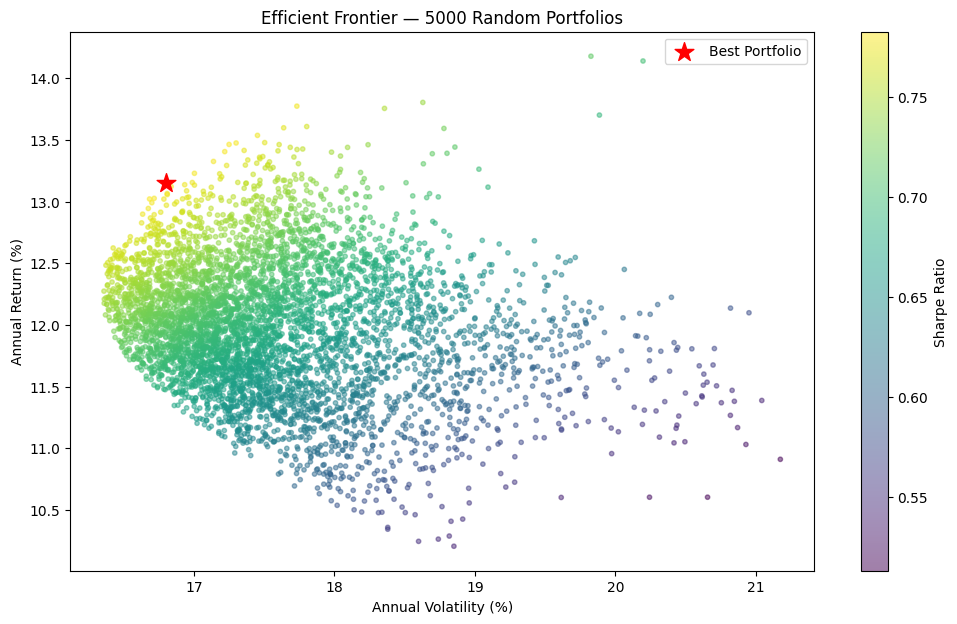

In [8]:
# Plot the Efficient Frontier
plt.figure(figsize=(12, 7))

scatter = plt.scatter(results[1], results[0], 
                      c=results[2], cmap='viridis', 
                      alpha=0.5, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')

# Highlight the best portfolio (highest Sharpe)
best_idx = results[2].argmax()
plt.scatter(results[1, best_idx], results[0, best_idx], 
            color='red', s=200, marker='*', 
            label='Best Portfolio', zorder=5)

plt.title('Efficient Frontier — 5000 Random Portfolios')
plt.xlabel('Annual Volatility (%)')
plt.ylabel('Annual Return (%)')
plt.legend()
plt.show()

In [9]:
# What does the best portfolio look like?
best_weights = weights_record[best_idx]

print("Optimal Portfolio Weights:")
for ticker, weight in zip(tickers, best_weights):
    print(f"  {ticker}: {weight*100:.2f}%")

print(f"\nExpected Annual Return: {results[0, best_idx]:.2f}%")
print(f"Expected Annual Volatility: {results[1, best_idx]:.2f}%")
print(f"Sharpe Ratio: {results[2, best_idx]:.4f}")

Optimal Portfolio Weights:
  RELIANCE.NS: 13.03%
  TCS.NS: 4.08%
  INFY.NS: 36.09%
  HDFCBANK.NS: 44.83%
  WIPRO.NS: 1.97%

Expected Annual Return: 13.15%
Expected Annual Volatility: 16.80%
Sharpe Ratio: 0.7825


## What I learned — Efficient Frontier

**Efficient Frontier:** A curve that shows the best possible portfolios —
ones that give maximum return for a given level of risk. Any portfolio 
inside the curve is suboptimal because you could get the same return 
with less risk by moving to the frontier.

**Optimal weights surprise:** The optimizer ignored TCS and Wipro almost 
completely, putting 81% into HDFC Bank and Infosys. This shows that 
diversification is not about equal weights — it's about finding the 
combination that maximizes return per unit of risk.

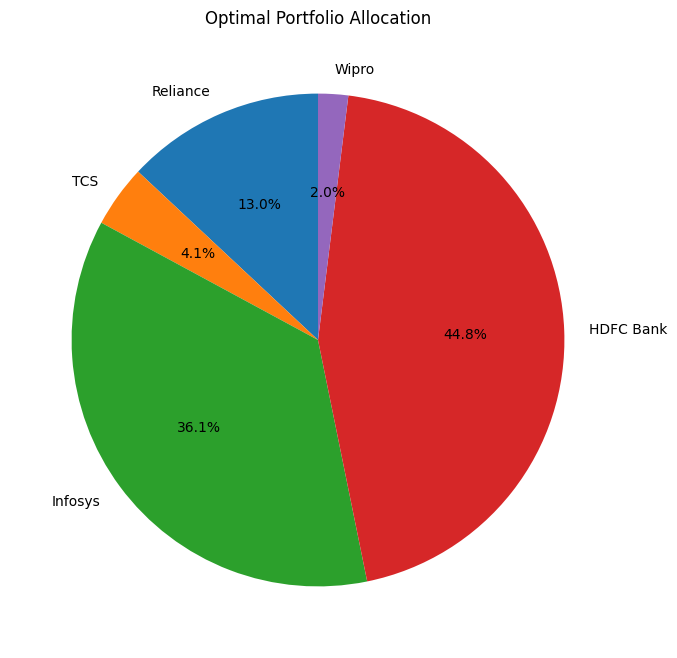

In [10]:
# Pie chart of optimal portfolio
stock_names = ['Reliance', 'TCS', 'Infosys', 'HDFC Bank', 'Wipro']

plt.figure(figsize=(8, 8))
plt.pie(best_weights, labels=stock_names, autopct='%1.1f%%', startangle=90)
plt.title('Optimal Portfolio Allocation')
plt.show()

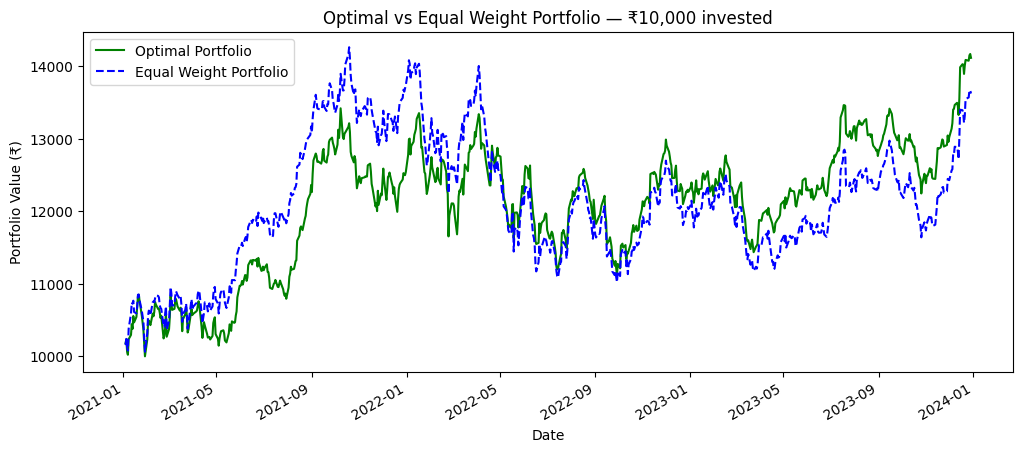

Optimal Portfolio final value: ₹14115
Equal Weight Portfolio final value: ₹13623


In [11]:
# How would the optimal portfolio have performed?
portfolio_returns = returns.dot(best_weights)
cumulative = (1 + portfolio_returns).cumprod() * 10000

plt.figure(figsize=(12, 5))
cumulative.plot(label='Optimal Portfolio', color='green')

# Compare with equal weight portfolio
equal_weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
equal_returns = returns.dot(equal_weights)
equal_cumulative = (1 + equal_returns).cumprod() * 10000

equal_cumulative.plot(label='Equal Weight Portfolio', color='blue', linestyle='--')

plt.title('Optimal vs Equal Weight Portfolio — ₹10,000 invested')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (₹)')
plt.legend()
plt.show()

print(f"Optimal Portfolio final value: ₹{cumulative.iloc[-1]:.0f}")
print(f"Equal Weight Portfolio final value: ₹{equal_cumulative.iloc[-1]:.0f}")

## Optimal vs Equal Weight Portfolio

**Equal Weight Portfolio:** Simply splits investment equally across 
all stocks — 20% each. Easy but ignores which stocks are actually better.

**Optimal Portfolio:** Uses math to find the best weights that maximize 
the Sharpe ratio — more money in stronger stocks, less in weaker ones.

**Result:** Optimal portfolio turned ₹10,000 into ₹14,115 vs ₹13,623 
for equal weight. The optimizer won by putting 81% into HDFC Bank and 
Infosys — the two strongest performers — and almost ignoring Wipro and TCS.

Small edge today, massive difference over decades due to compounding.